In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("amazon_sales.csv")

In [4]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [5]:
df.shape

(5604, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5604 entries, 0 to 5603
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               5604 non-null   int64  
 1   Order ID            5604 non-null   object 
 2   Date                5604 non-null   object 
 3   Status              5604 non-null   object 
 4   Fulfilment          5604 non-null   object 
 5   Sales Channel       5604 non-null   object 
 6   ship-service-level  5604 non-null   object 
 7   Style               5604 non-null   object 
 8   SKU                 5604 non-null   object 
 9   Category            5604 non-null   object 
 10  Size                5604 non-null   object 
 11  ASIN                5604 non-null   object 
 12  Courier Status      5276 non-null   object 
 13  Qty                 5604 non-null   int64  
 14  currency            5232 non-null   object 
 15  Amount              5232 non-null   float64
 16  ship-c

In [7]:
df.isnull().sum()

index                    0
Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
SKU                      0
Category                 0
Size                     0
ASIN                     0
Courier Status         328
Qty                      0
currency               372
Amount                 372
ship-city                2
ship-state               2
ship-postal-code         2
ship-country             2
promotion-ids         1963
B2B                      0
fulfilled-by          3792
Unnamed: 22           5604
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

index                   0.000000
Order ID                0.000000
Date                    0.000000
Status                  0.000000
Fulfilment              0.000000
Sales Channel           0.000000
ship-service-level      0.000000
Style                   0.000000
SKU                     0.000000
Category                0.000000
Size                    0.000000
ASIN                    0.000000
Courier Status          5.852962
Qty                     0.000000
currency                6.638116
Amount                  6.638116
ship-city               0.035689
ship-state              0.035689
ship-postal-code        0.035689
ship-country            0.035689
promotion-ids          35.028551
B2B                     0.000000
fulfilled-by           67.665953
Unnamed: 22           100.000000
dtype: float64

In [9]:
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("***"*15)

Order ID
404-7386718-9479548    7
171-2644368-7969167    6
402-1482834-5739526    5
408-7798096-6116356    5
408-0304814-7806756    5
                      ..
403-0573290-1986726    1
405-4245425-2397142    1
402-4055047-1889167    1
406-8755955-7160337    1
406-7807733-3785945    1
Name: count, Length: 5274, dtype: int64
*********************************************
Date
4/30/2022    1481
4/29/2022    1466
4/28/2022    1416
4/27/2022    1241
Name: count, dtype: int64
*********************************************
Status
Shipped                         3322
Shipped - Delivered to Buyer    1378
Cancelled                        798
Shipped - Returned to Seller     102
Shipped - Rejected by Buyer        2
Shipped - Lost in Transit          2
Name: count, dtype: int64
*********************************************
Fulfilment
Amazon      3792
Merchant    1812
Name: count, dtype: int64
*********************************************
Sales Channel 
Amazon.in     5588
Non-Amazon      16
Name: coun

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,5604.0,2801.500000,1617.879785,0.0,1400.75,2801.50,4202.25,5603.0
Qty,5604.0,0.902748,0.414359,0.0,1.00,1.00,1.00,15.0
Amount,5232.0,623.945227,274.976874,0.0,435.00,570.48,771.00,2224.0
ship-postal-code,5602.0,465635.498215,191997.982840,110001.0,382032.75,500027.00,600013.50,989898.0
Unnamed: 22,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.describe(include="object").T

,count,unique,top,freq
Order ID,5604,5274,404-7386718-9479548,7
Date,5604,4,4/30/2022,1481
Status,5604,6,Shipped,3322
Fulfilment,5604,2,Amazon,3792
Sales Channel,5604,2,Amazon.in,5588
ship-service-level,5604,2,Expedited,3712
Style,5604,816,JNE3405,167
SKU,5604,2227,J0230-SKD-S,39
Category,5604,8,Set,2291
Size,5604,11,M,985


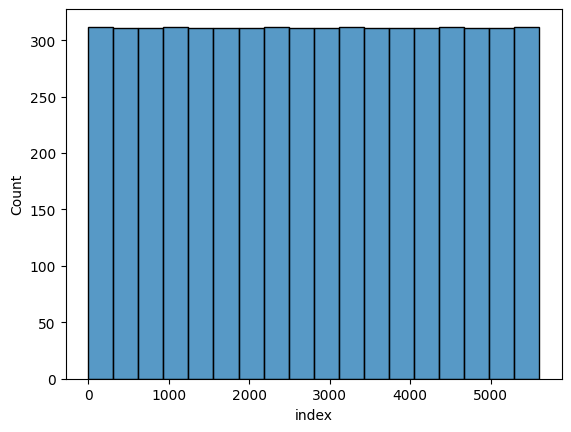

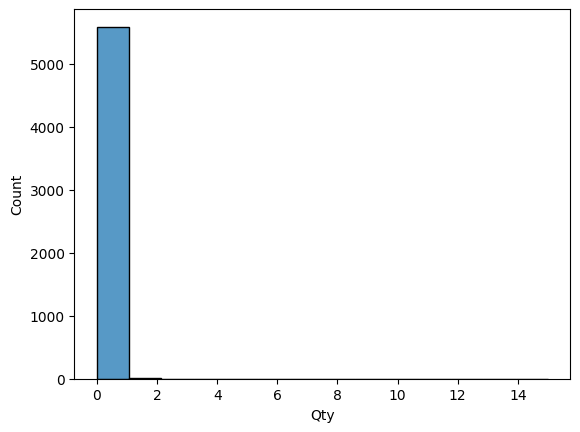

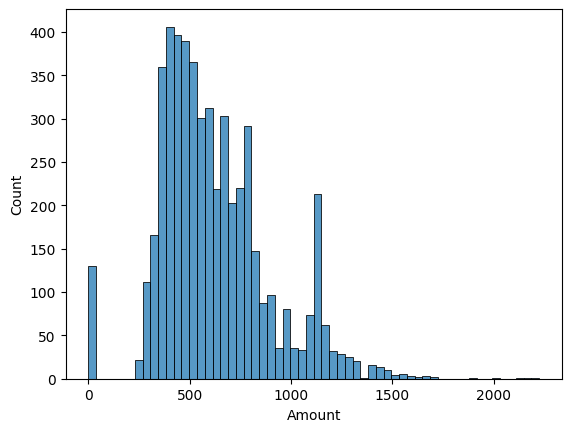

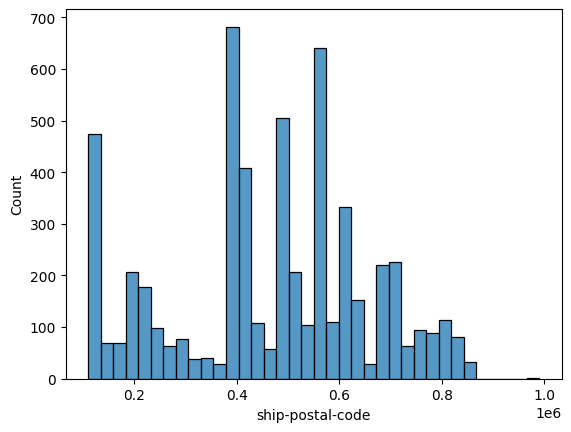

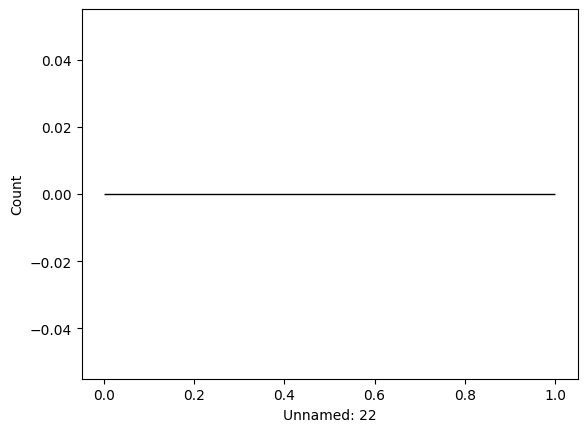

In [12]:
for i in df.select_dtypes(include="number").columns:
    sns.histplot(data=df, x=i)
    plt.show()

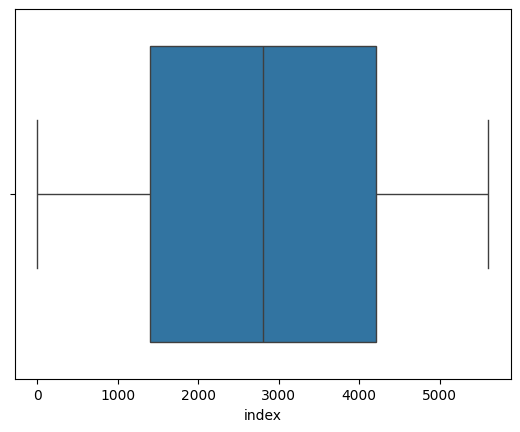

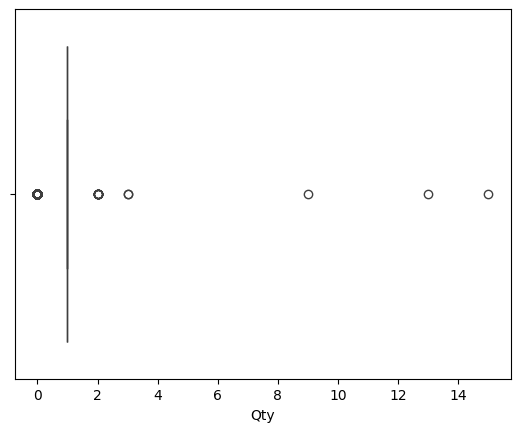

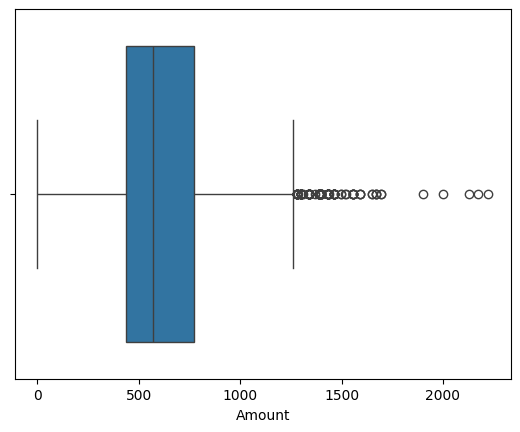

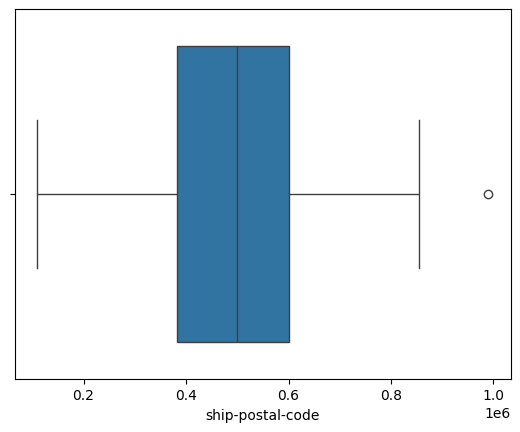

ValueError: List of boxplot statistics and `positions` values must have same the length

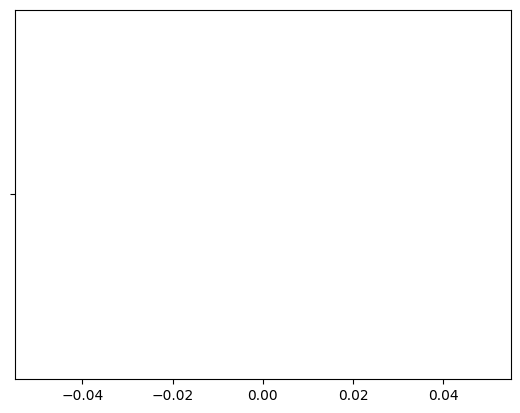

In [13]:
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df, x=i)
    plt.show()

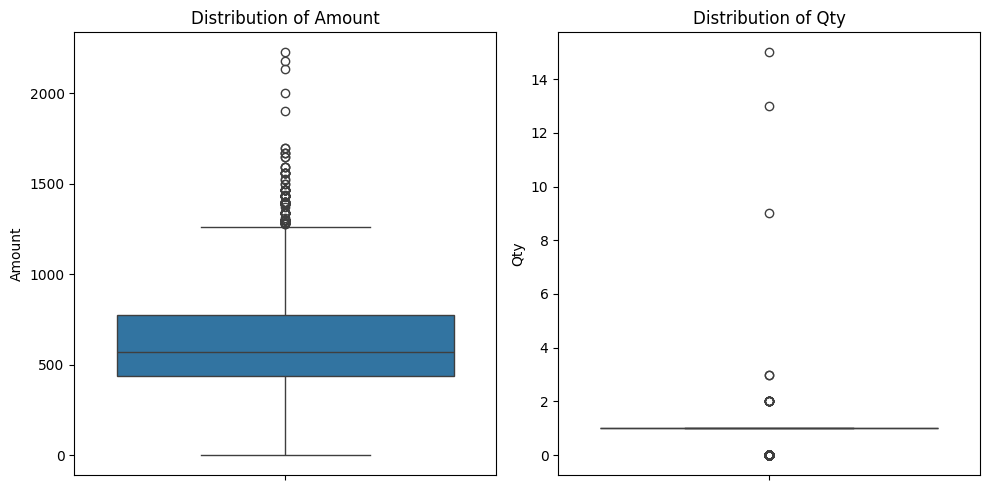

In [ ]:

cols_to_plot = ['Amount', 'Qty'] 


plt.figure(figsize=(10, 5))

for i, col in enumerate(cols_to_plot):
    plt.subplot(1, len(cols_to_plot), i+1)
    sns.boxplot(data=df, y=col) 
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Sales & Inventory Distribution**

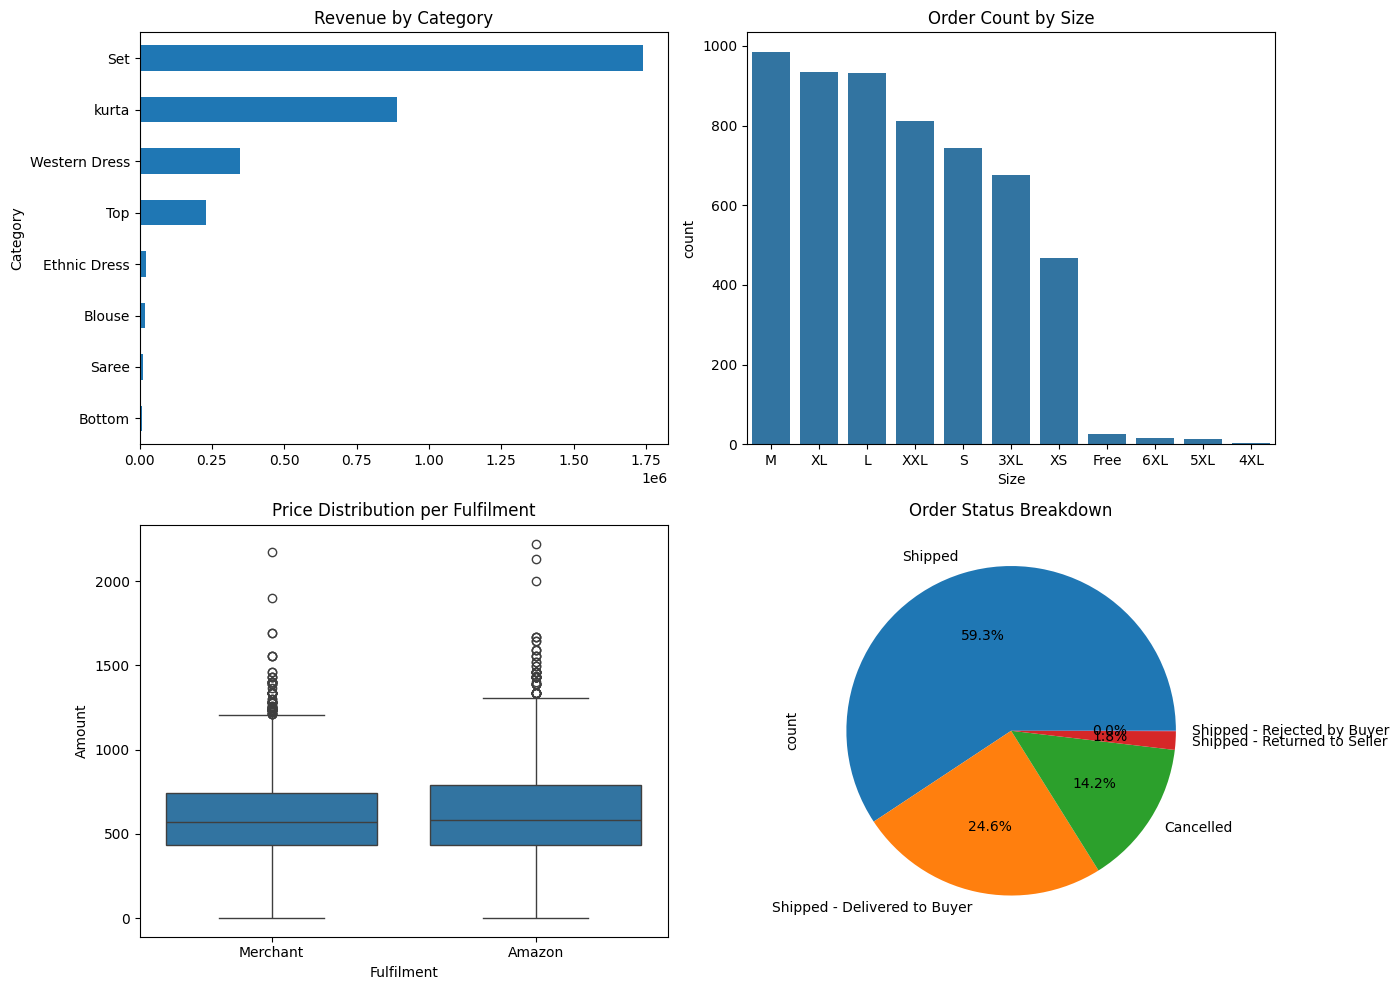

In [ ]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
df.groupby('Category')['Amount'].sum().sort_values().plot(kind='barh')
plt.title('Revenue by Category')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Size', order=df['Size'].value_counts().index)
plt.title('Order Count by Size')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Fulfilment', y='Amount')
plt.title('Price Distribution per Fulfilment')

plt.subplot(2, 2, 4)
df['Status'].value_counts().nlargest(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('Order Status Breakdown')

plt.tight_layout()
plt.show()

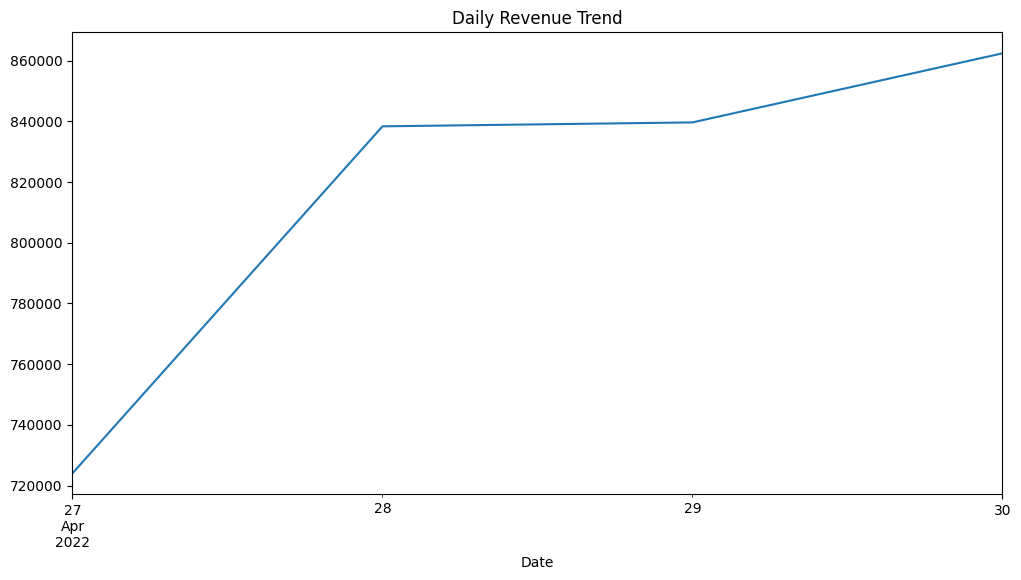

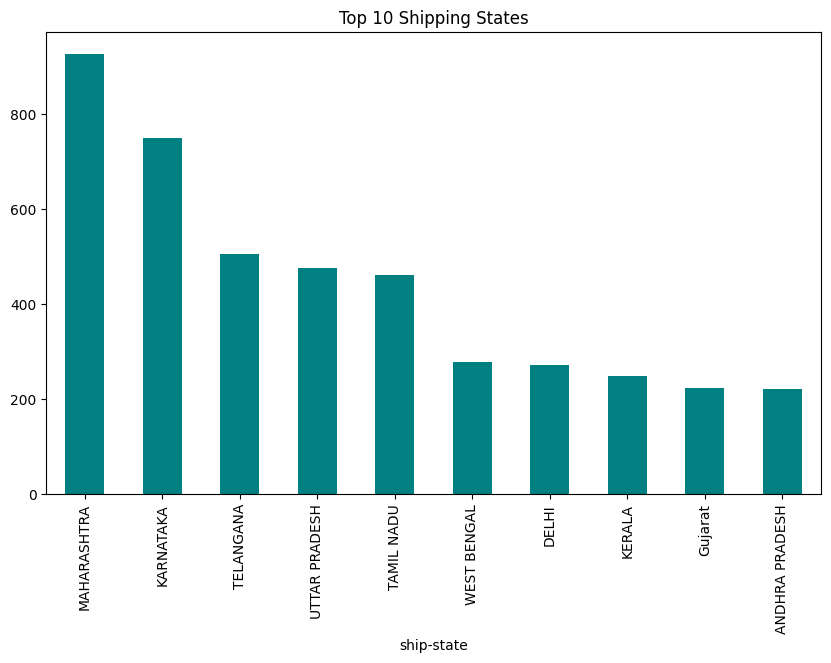

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(12, 6))
df.groupby('Date')['Amount'].sum().plot()
plt.title('Daily Revenue Trend')
plt.show()

plt.figure(figsize=(10, 6))
df['ship-state'].value_counts().nlargest(10).plot(kind='bar', color='teal')
plt.title('Top 10 Shipping States')
plt.show()

In [ ]:
stats = {
    "Total Revenue": df['Amount'].sum(),
    "Average Ticket Size": df['Amount'].mean(),
    "B2B Percentage": (df['B2B'].sum() / len(df)) * 100,
    "Top SKU": df['SKU'].mode()[0]
}

for key, val in stats.items():
    print(f"{key}: {val:.2f}" if isinstance(val, float) else f"{key}: {val}")

Total Revenue: 3264481.43
Average Ticket Size: 623.95
B2B Percentage: 0.75
Top SKU: J0230-SKD-S


Total Realized Revenue: 840850.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_12800\4262614979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fulfilment', y='Amount', estimator=sum, palette='viridis')


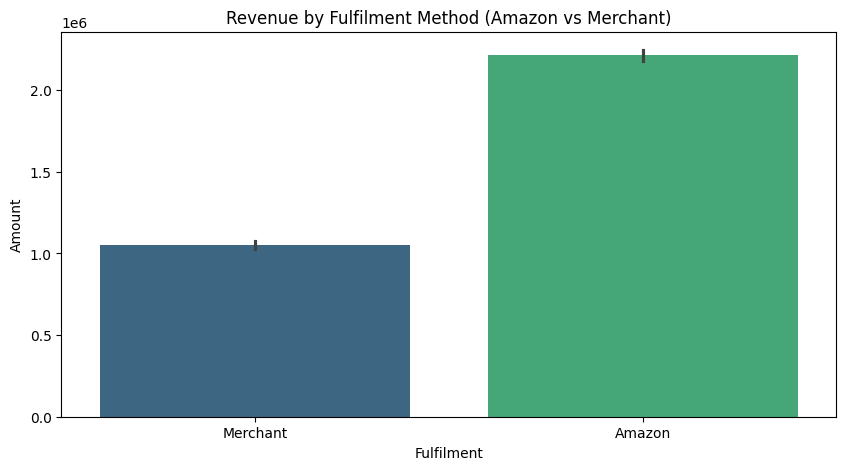

In [14]:
success_orders = df[df['Status'] == 'Shipped - Delivered to Buyer']
print(f"Total Realized Revenue: {success_orders['Amount'].sum()}")


plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Fulfilment', y='Amount', estimator=sum, palette='viridis')
plt.title('Revenue by Fulfilment Method (Amazon vs Merchant)')
plt.show()

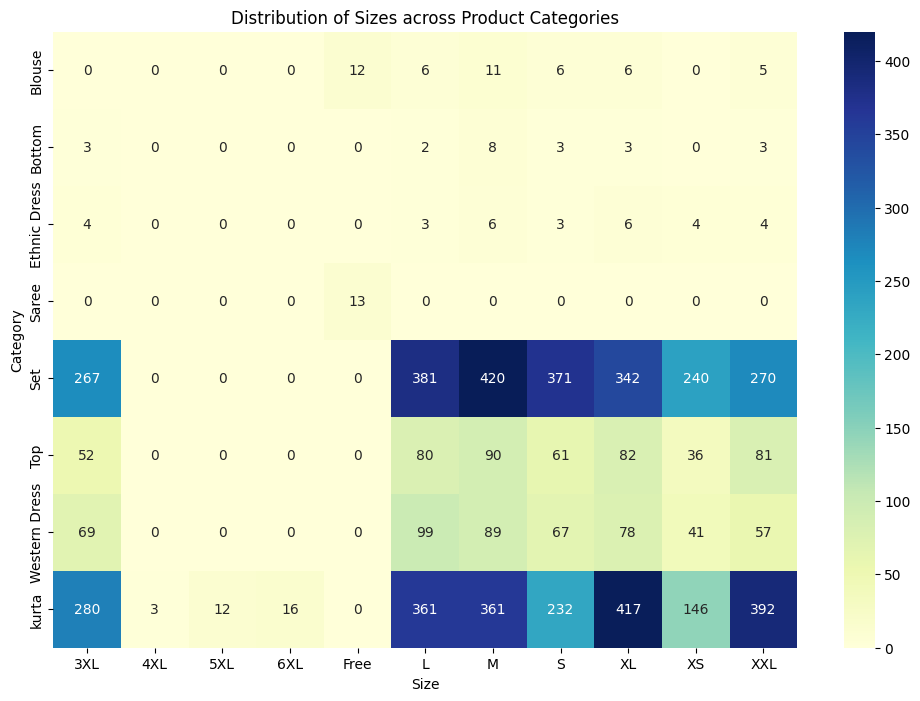

In [15]:

cat_size_dist = df.groupby(['Category', 'Size']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(cat_size_dist, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Distribution of Sizes across Product Categories')
plt.show()

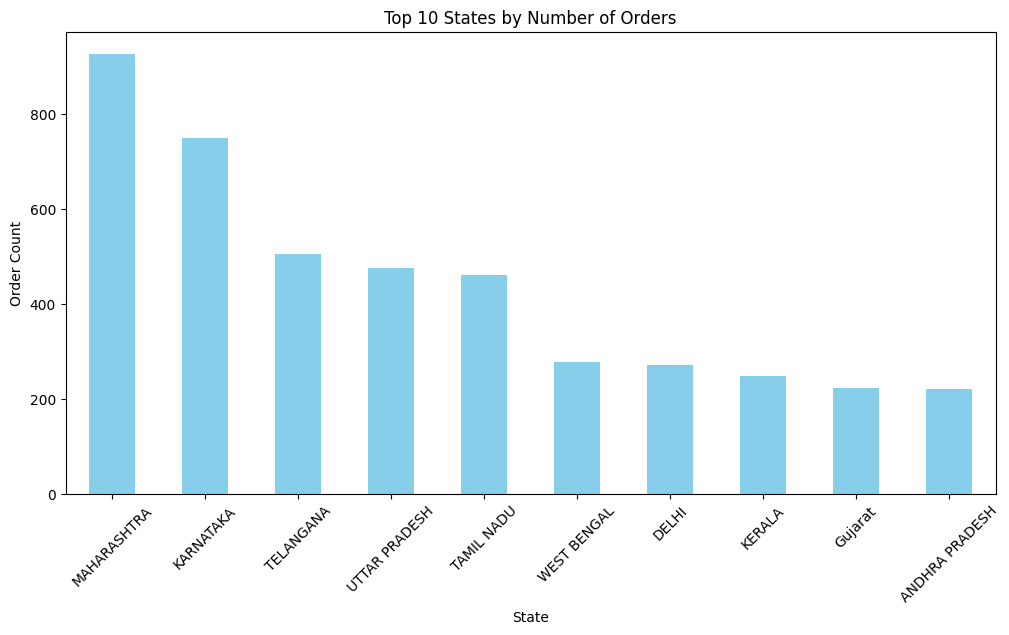

In [16]:

top_states = df['ship-state'].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
top_states.plot(kind='bar', color='skyblue')
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()

Average Order Value:
B2B
False    623.603588
True     669.435897
Name: Amount, dtype: float64


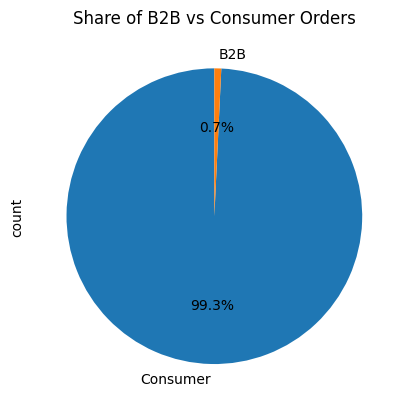

In [17]:

aov_comparison = df.groupby('B2B')['Amount'].mean()
print("Average Order Value:")
print(aov_comparison)

df['B2B'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Consumer', 'B2B'], startangle=90)
plt.title('Share of B2B vs Consumer Orders')
plt.show()

Target Variable Selection: Amount (Order Revenue)

Drop Irrelevant

In [18]:
y = df['Amount']          
X = df.drop(columns=['Amount'])  

drop_cols = [
    'index', 'Order ID', 'ASIN', 'SKU', 'ship-postal'
]

df_fs = df.drop(columns=drop_cols, errors='ignore')


Encode Categorical Variables (one hot)

In [19]:
X_encoded = pd.get_dummies(X, drop_first=True)


Feature Importance (Correlation with Target)

In [20]:
corr = X_encoded.corrwith(y).abs().sort_values(ascending=False)

selected_corr_features = corr[corr >= 0.1].index.tolist()
selected_corr_features
corr.head(10)


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Category_Set                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            0.570257
Category_kurta                                                                                                                                                                                                                                                                                                                         

Correlation with Target (Amount)

In [21]:
corr = X_encoded.corrwith(y).abs().sort_values(ascending=False)

corr.head(10)

Category_Set                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            0.570257
Category_kurta                                                                                                                                                                                                                                                                                                                         

In [22]:
selected_corr_features = corr[corr >= 0.1].index

Chi-Square Test (Categorical Feature Importance)

In [24]:
df['High_Value'] = (df['Amount'] > df['Amount'].median()).astype(int)


In [25]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

chi_features = ['Category', 'Size', 'ship-state', 'fulfilled-by', 'promotion-ids']

chi_scores = {}

for col in chi_features:
    le = LabelEncoder()
    X = le.fit_transform(df[col])
    chi, p = chi2(X.reshape(-1,1), df['High_Value'])
    chi_scores[col] = p[0]

chi_scores


{'Category': np.float64(1.3171620109179224e-168),
 'Size': np.float64(0.03045387321509106),
 'ship-state': np.float64(1.1382886116669482e-05),
 'fulfilled-by': np.float64(0.6748073120012428),
 'promotion-ids': np.float64(0.033544099689942604)}

In [26]:
selected_chi_features = [k for k,v in chi_scores.items() if v < 0.05]
selected_chi_features


['Category', 'Size', 'ship-state', 'promotion-ids']

Final Feature Set

In [27]:
final_features = list(set(selected_corr_features).union(selected_chi_features))

final_features = [f for f in final_features if f != 'Amount']

final_features = [
    f for f in final_features
    if not f.startswith('Style_') and not f.startswith('promotion-ids_')
]

final_features


['Category_Top',
 'Size',
 'ship-state',
 'ASIN_B08XNJ19QH',
 'Category',
 'SKU_J0230-SKD-S',
 'Category_Western Dress',
 'Category_Set',
 'promotion-ids',
 'Category_kurta']

In [28]:
print('Amount' in final_features)


False


Train–Test Split

In [29]:
df_rf = df.dropna(subset=['Amount'])

y = df_rf['Amount']
X = df_rf.drop(columns=['Amount'])

X_encoded = pd.get_dummies(X, drop_first=True)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


Random Forest Regressor

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

rf_importance.head(15)


High_Value                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              0.570980
Category_Set                                                                                                                                                                                                                                                           

Select Important Features

In [33]:
selected_rf_features = rf_importance[rf_importance > 0.01].index.tolist()

selected_rf_features


['High_Value',
 'Category_Set',
 'Style_SET324',
 'Style_J0230',
 'promotion-ids_Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC Free-Financing Universal Merchant AAT-DSJ2QRXXWXVMQ,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-ETXQ3XXWMRXBG,Amazon PLCC Free-Financing Universal Merchant AAT-7X3XCTYG64VBE,Amazon PLCC Free-Financing Universal Merchant AAT-7CHGD3WTS3MHM,Amazon PLCC Free-Financing Universal Merchant AAT-26ZDKNME27X42,Amazon PLCC Free-Financing Universal Merchant AAT-4ZF5KN6E4LJK4,Amazon PLCC Free-Financing Universal Merchant AAT-7RCXIKUAX7DDY,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811',
 'Style_J0280',
 'Style_J0003']

In [34]:
# X_rf_final = X_encoded[selected_rf_features]

# X_rf_final.head()   

# {if we need to see final dataset}



END Senor

## MACHINE LEARNING PREDICTION

Historical Data Range: 2022-04-27 00:00:00 to 2022-04-30 00:00:00


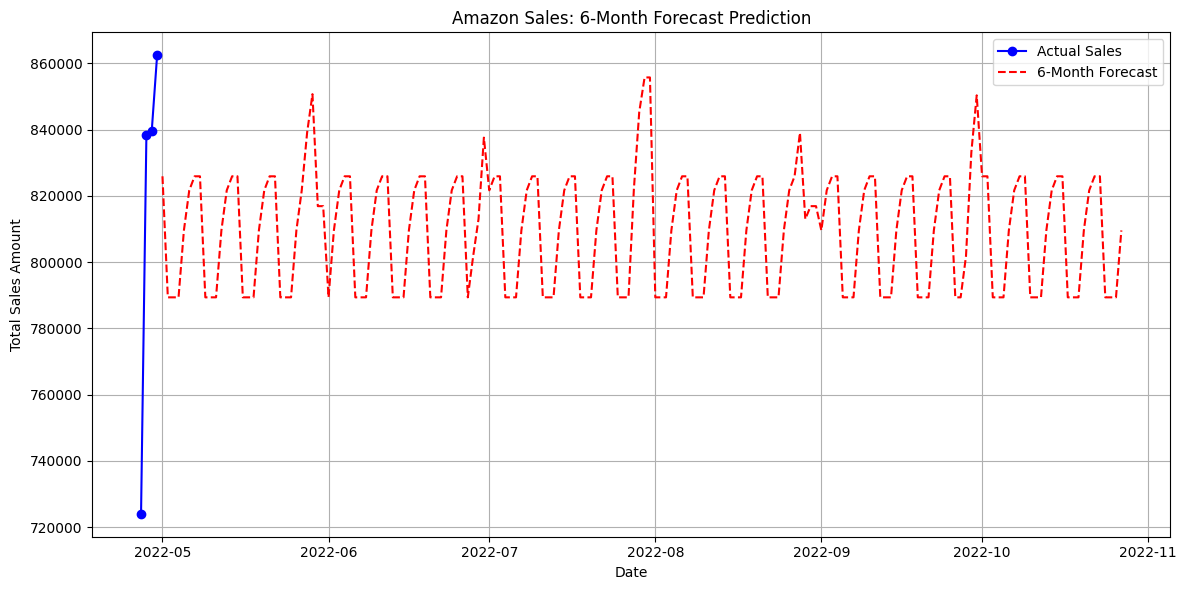

Success! Results saved to 'future_sales_predictions.csv' and 'sales_forecast_plot.png'.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from datetime import timedelta

# 1. Load the data
try:
    # Ensure the file name matches your CSV
    df = pd.read_csv('amazon_sales.csv', low_memory=False)
except FileNotFoundError:
    print("Error: 'amazon_sales.csv' not found.")
    exit()

# 2. Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
# Group sales by date to get daily totals
daily_sales = df.groupby('Date')['Amount'].sum().reset_index()
daily_sales = daily_sales.sort_values('Date')

print(f"Historical Data Range: {daily_sales['Date'].min()} to {daily_sales['Date'].max()}")

# 3. Feature Engineering: Convert dates into numbers the model can understand
def create_features(df):
    df = df.copy()
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofyear'] = df['Date'].dt.dayofyear
    return df

daily_sales = create_features(daily_sales)

# Features (X) and Target (y)
X = daily_sales[['day', 'dayofweek', 'month', 'year', 'dayofyear']]
y = daily_sales['Amount']

# 4. Train the Model
# We use Random Forest, which is great for finding patterns in tabular data
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 5. Create Future Dates (Next 180 days / 6 months)
last_date = daily_sales['Date'].max()
future_dates = [last_date + timedelta(days=x) for x in range(1, 181)]
future_df = pd.DataFrame({'Date': future_dates})
future_df = create_features(future_df)

# 6. Predict Future Sales
future_X = future_df[['day', 'dayofweek', 'month', 'year', 'dayofyear']]
future_df['Predicted_Amount'] = model.predict(future_X)

# 7. Visualization
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Date'], daily_sales['Amount'], label='Actual Sales', color='blue', marker='o')
plt.plot(future_df['Date'], future_df['Predicted_Amount'], label='6-Month Forecast', color='red', linestyle='--')
plt.title('Amazon Sales: 6-Month Forecast Prediction')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('sales_forecast_plot.png')
plt.show()

# 8. Save the prediction to a CSV
future_df[['Date', 'Predicted_Amount']].to_csv('future_sales_predictions.csv', index=False)
print("Success! Results saved to 'future_sales_predictions.csv' and 'sales_forecast_plot.png'.")

--- CANCELLED ORDER PREDICTION REPORT ---
Accuracy: 0.9580
F1-Score: 0.6765
ROC-AUC:  0.8432

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       958
           1       0.98      0.52      0.68        89

    accuracy                           0.96      1047
   macro avg       0.97      0.76      0.83      1047
weighted avg       0.96      0.96      0.95      1047


Confusion Matrix saved as 'cancellation_cm.png'


--- SHIPPING SERVICE LEVEL PREDICTION REPORT ---
Accuracy: 0.9933
F1-Score: 0.9950


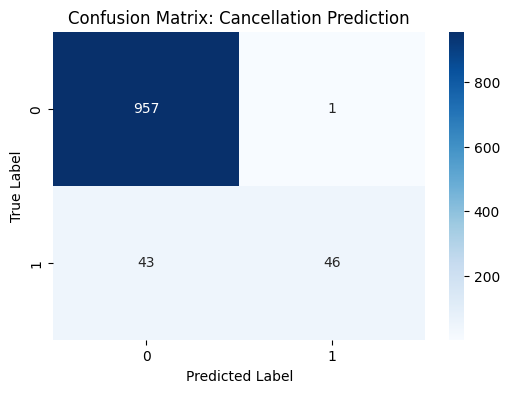

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, roc_auc_score

# 1. Load Data
df = pd.read_csv('amazon_sales.csv', low_memory=False)

# 2. Preprocessing
def prepare_data(df):
    # Drop IDs and columns with too many missing values
    cols_to_drop = ['index', 'Order ID', 'SKU', 'ASIN', 'promotion-ids', 'Unnamed: 22', 'fulfilled-by', 'Sales Channel ', 'currency']
    df_ml = df.drop(columns=cols_to_drop).dropna(subset=['Amount'])
    
    # Fill missing values
    df_ml['ship-state'] = df_ml['ship-state'].fillna('Unknown')
    
    # Encode targets
    df_ml['is_cancelled'] = df_ml['Status'].apply(lambda x: 1 if 'Cancelled' in x else 0)
    df_ml['is_expedited'] = df_ml['ship-service-level'].apply(lambda x: 1 if 'Expedited' in x else 0)
    
    # Encode categorical features
    cat_features = ['Category', 'Size', 'Fulfilment', 'ship-state', 'Style']
    le = LabelEncoder()
    for col in cat_features:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        
    return df_ml

data = prepare_data(df)
features = ['Category', 'Size', 'Fulfilment', 'ship-state', 'Style', 'Amount', 'Qty']

# --- TASK 1: CANCELLED PREDICTION (Gradient Boosting) ---
X = data[features]
y = data['is_cancelled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
y_pred = model_gb.predict(X_test)
y_prob = model_gb.predict_proba(X_test)[:, 1]

print("--- CANCELLED ORDER PREDICTION REPORT ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# --- VISUALIZATION: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Cancellation Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('cancellation_cm.png')
print("\nConfusion Matrix saved as 'cancellation_cm.png'")

# --- TASK 2: SHIPPING LEVEL PREDICTION (Random Forest) ---
y_ship = data['is_expedited']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_ship, test_size=0.2, random_state=42)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_s, y_train_s)
y_pred_s = model_rf.predict(X_test_s)

print("\n\n--- SHIPPING SERVICE LEVEL PREDICTION REPORT ---")
print(f"Accuracy: {accuracy_score(y_test_s, y_pred_s):.4f}")
print(f"F1-Score: {f1_score(y_test_s, y_pred_s):.4f}")

--- MODEL 2: SHIPPING SERVICE LEVEL PREDICTION ---
Accuracy:  0.7361
F1-Score:  0.7246
Precision: 0.7252
Recall:    0.7361

Full Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.81       697
           1       0.64      0.48      0.55       349

    accuracy                           0.74      1046
   macro avg       0.70      0.67      0.68      1046
weighted avg       0.73      0.74      0.72      1046



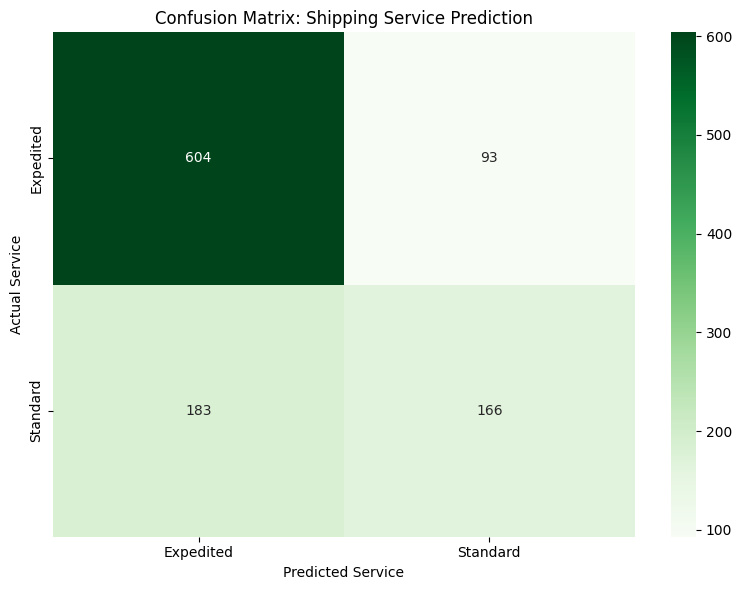


Success! Confusion matrix saved as 'shipping_confusion_matrix.png'


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, classification_report, confusion_matrix)

# 1. Load the dataset
# Ensure 'amazon_sales.csv' is in the same folder as this script
try:
    df = pd.read_csv('amazon_sales.csv', low_memory=False)
except FileNotFoundError:
    print("Error: 'amazon_sales.csv' not found. Please check the file path.")
    exit()

# 2. Data Preprocessing
# We select features that are known at the time of order placement
features = ['Category', 'Size', 'Style', 'Amount', 'Qty', 'ship-state']
target = 'ship-service-level'

# Drop rows with missing values in target or features
df_ml = df.dropna(subset=[target] + features).copy()

# Encode Categorical features into numbers
le = LabelEncoder()
for col in ['Category', 'Size', 'Style', 'ship-state']:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Encode the Target (Expedited vs Standard)
df_ml[target] = le.fit_transform(df_ml[target])
# Note: Usually 0 = Expedited, 1 = Standard (depends on alphabetical order)

# 3. Split Data into Training and Testing sets
X = df_ml[features]
y = df_ml[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = model.predict(X_test)

# 6. Calculate Metrics (Required by your instructor)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

print("--- MODEL 2: SHIPPING SERVICE LEVEL PREDICTION ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Shipping Service Prediction')
plt.xlabel('Predicted Service')
plt.ylabel('Actual Service')
plt.tight_layout()
plt.savefig('shipping_confusion_matrix.png')
plt.show()

print("\nSuccess! Confusion matrix saved as 'shipping_confusion_matrix.png'")